저장된 yolo v10 모델을 사용하여 이미지에서 객체 검출을 수행하는 코드

# 필요 라이브러리 설치

In [5]:
pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 11.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.2
    Uninstalling pip-24.2:
      Successfully uninstalled pip-24.2
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
pip install -q supervision roboflow

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install ultralytics

  Using cached torch-2.5.1-cp311-cp311-win_amd64.whl.metadata (28 kB)
  Using cached torchvision-0.20.1-cp311-cp311-win_amd64.whl.metadata (6.2 kB)
  Using cached py_cpuinfo-9.0.0-py3-none-any.whl.metadata (794 bytes)
  Using cached pandas-2.2.3-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pytz-2024.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2024.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached filelock-3.16.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached fsspec-2024.10.0-py3-none-any.whl.metadata (11 kB)
  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/901.3 kB ? eta -:--:--
   --------------------------------------- 901.3/901.3 kB 10.3 MB/s eta 0:00:00
Using cached pandas-2.2.3-cp311-cp311-wi

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [6]:
pip install -q git+https://github.com/THU-MIG/yolov10.git

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
pip install huggingface-hub

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


# 객체 검출 수행

In [8]:
from ultralytics import YOLOv10

# 어떤 객체가 검출되었는지 확인
model = YOLOv10(f'v6_nano.pt')
results = model(source=f'images_2/img_60.jpg', conf=0.5)


image 1/1 C:\Users\user\jupyter\deep_learning\images_2\img_60.jpg: 640x384 1 left, 1 right, 63.1ms
Speed: 2.0ms preprocess, 63.1ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 384)


In [9]:
from ultralytics import YOLOv10

# 어떤 객체가 검출되었는지 확인 + bounding box top_left_x, top_left_y, bottom_right_x, bottom_right_y 확인
model = YOLOv10(f'v6_nano.pt')
results = model(source=f'images_2/img_60.jpg', conf=0.5)

print(results[0].boxes.xyxy)
print(results[0].boxes.conf)

# 0: down, 1: left, 2: right, 3: tilt_left, 4: tilt_right, 5:up
print(results[0].boxes.cls)


image 1/1 C:\Users\user\jupyter\deep_learning\images_2\img_60.jpg: 640x384 1 left, 1 right, 72.1ms
Speed: 2.0ms preprocess, 72.1ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 384)
tensor([[ 67.0654, 390.3456, 498.8047, 661.7946],
        [  0.0000, 391.9738, 455.1028, 655.5961]])
tensor([0.9469, 0.8673])
tensor([2., 1.])



0: 640x384 1 left, 1 right, 68.5ms
Speed: 2.9ms preprocess, 68.5ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 384)


SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.


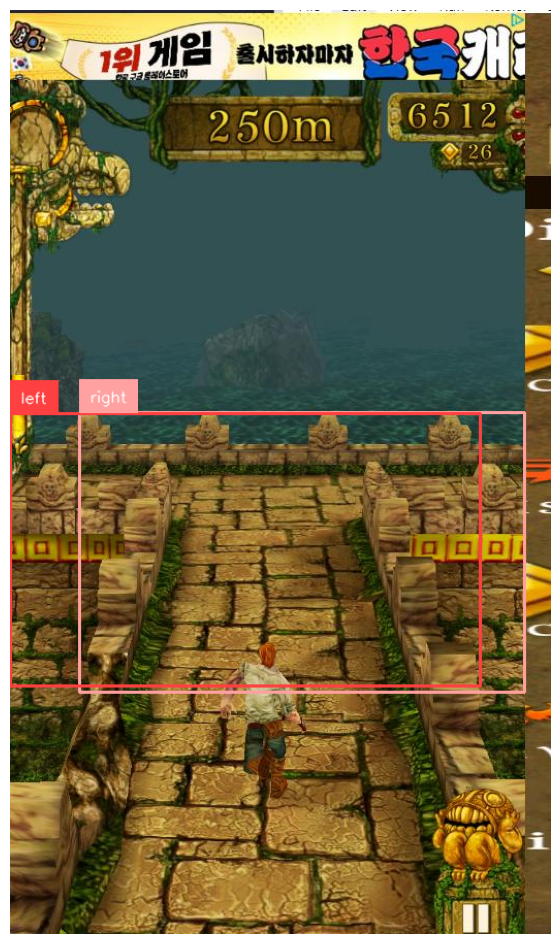

In [12]:
import cv2
import supervision as sv
from ultralytics import YOLOv10

# 어떤 객체가 검출되었는지 확인 + bounding box top_left_x, top_left_y, bottom_right_x, bottom_right_y 확인 + 이미지로 확인
model = YOLOv10(f'v6_nano.pt')
image = cv2.imread(f'images_2/img_60.jpg')
results = model(image, conf=0.5)[0]
detections = sv.Detections.from_ultralytics(results)

bounding_box_annotator = sv.BoundingBoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = bounding_box_annotator.annotate(
    scene=image, detections=detections)
annotated_image = label_annotator.annotate(
    scene=annotated_image, detections=detections)

sv.plot_image(annotated_image)